In [ ]:
from google.colab import drive
drive.mount('/content/drive')

전체 컬럼: ['date', '누적량1', '시작', '종료', '설정EC(dS)', '현재EC(dS)', '설정PH(pH)', '현재PH(pH)', '일출시간', '일몰시간', '현재일사(W)', '누적일사(J)', 'J/Day', 'EC급액', 'EC배액', 'pH급액', 'pH배액', '저울급액', '저울배액', '온도토양', '온도급액', '온도배액', '내부이산화탄소', '내부광량', '내부PT100온도센서1번건구', '내부PT100온도센서2번습구', '내부PT100온도센서3번', '내부PT100센서를이용한계산습도']
선택된 숫자형 컬럼: ['누적량1', '설정EC(dS)', '현재EC(dS)', '설정PH(pH)', '현재PH(pH)', '현재일사(W)', '누적일사(J)', 'J/Day', 'EC급액', 'EC배액', 'pH급액', 'pH배액', '저울급액', '저울배액', '온도토양', '온도급액', '온도배액', '내부이산화탄소', '내부광량', '내부PT100온도센서1번건구', '내부PT100온도센서2번습구', '내부PT100온도센서3번', '내부PT100센서를이용한계산습도']
결측치 상태 (정규화 전):
누적량1                      0
설정EC(dS)                  0
현재EC(dS)                  0
설정PH(pH)                  0
현재PH(pH)                  0
현재일사(W)                   0
누적일사(J)                   0
J/Day                     0
EC급액                 133609
EC배액                 133609
pH급액                 133609
pH배액                 133609
저울급액                 133609
저울배액                 133609
온도토양                 133609

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

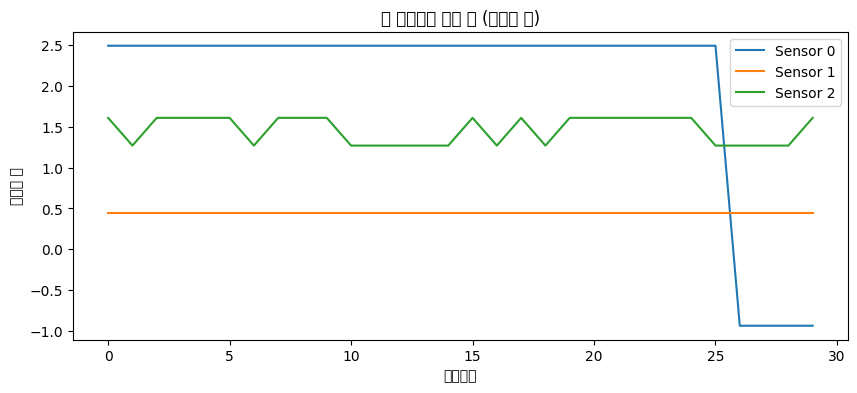

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. CSV 파일 불러오기 (경로에 맞게 수정)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/content/TS_Timeseries/tom1/토마토_환경데이터_1번농가(그린CS).csv')

# 1-1. 파일의 전체 컬럼명을 먼저 확인하여 날짜 컬럼을 정확히 파악
print("전체 컬럼:", df.columns.tolist())

# 2. 날짜/시간 컬럼 처리
# (예시에서는 'date' 컬럼이라고 가정하였으나, 실제 컬럼명이 다르면 그에 맞게 수정하세요)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

# 3. 숫자형 센서 데이터만 선택 (불필요한 텍스트, 설정값 등 제외)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("선택된 숫자형 컬럼:", numeric_cols)
df_numeric = df[numeric_cols].copy()

# 3-1. 결측치 상태 확인 (정규화 전)
print("결측치 상태 (정규화 전):")
print(df_numeric.isnull().sum())

# 4. 결측치 처리: 선형 보간법 적용 (필요시 'limit_direction'도 확인)
df_numeric.interpolate(method='linear', limit_direction='both', inplace=True)
print("결측치 상태 (보간 후):")
print(df_numeric.isnull().sum())

# 5. 정규화: 센서별 값 범위가 다르므로 StandardScaler 사용
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

# 5-1. 정규화 후 DataFrame을 만들어 통계치 확인 (각 센서별 분포 확인)
df_scaled = pd.DataFrame(data_scaled, columns=df_numeric.columns)
print("정규화 후 기술 통계:\n", df_scaled.describe())

# 6. 시계열 시퀀스 구성: 예를 들어 30 타임스텝씩 시퀀스 구성
def create_sequences(data, seq_len=30):
    sequences = []
    targets = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
        targets.append(data[i+seq_len])
    return np.array(sequences), np.array(targets)

seq_length = 30
X_cs, y_cs = create_sequences(data_scaled, seq_length)
print("X_cs shape:", X_cs.shape, "y_cs shape:", y_cs.shape)

# 7. 간단한 시각화: 첫 시퀀스의 여러 센서 값 확인 (예: 첫 3개 센서)
plt.figure(figsize=(10, 4))
for sensor_idx in range(min(3, X_cs.shape[2])):
    plt.plot(X_cs[0, :, sensor_idx], label=f"Sensor {sensor_idx}")
plt.title("첫 시퀀스의 센서 값 (정규화 후)")
plt.xlabel("타임스텝")
plt.ylabel("스케일 값")
plt.legend()
plt.show()


In [ ]:
# 신뢰 가능한 센서만 선택 (예시: 결측치 없고, 극단값 없는 것)
selected_cols = [
    '누적량1',
    '현재EC(dS)',
    '현재PH(pH)',
    '현재일사(W)',
    '누적일사(J)',
    'J/Day'
]
df_numeric = df[selected_cols].copy()


In [ ]:
# 이상치 클리핑 (특정 범위를 벗어나면 잘라냄)
df_numeric = df_numeric.clip(lower=df_numeric.quantile(0.01), upper=df_numeric.quantile(0.99), axis=1)

# 정규화 다시 적용
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

# 시퀀스 생성도 다시
X_cs, y_cs = create_sequences(data_scaled, seq_len=30)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

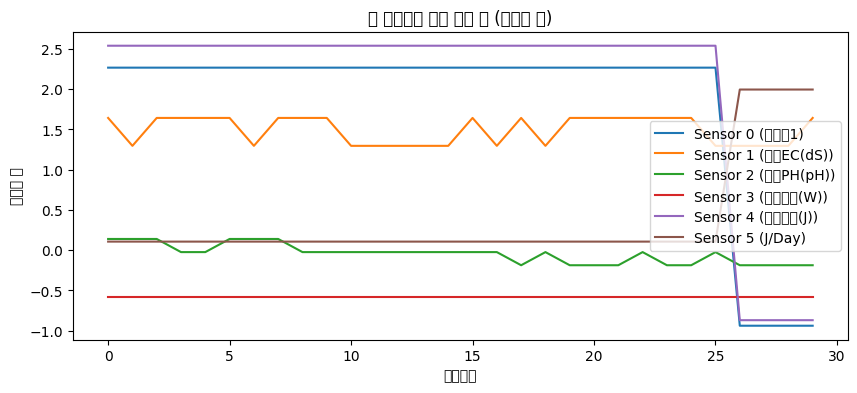

In [ ]:
# 처음 시퀀스의 센서값을 다시 시각화
plt.figure(figsize=(10, 4))
for i in range(len(selected_cols)):
    plt.plot(X_cs[0, :, i], label=f'Sensor {i} ({selected_cols[i]})')
plt.title("첫 시퀀스의 선택 센서 값 (정규화 후)")
plt.xlabel("타임스텝")
plt.ylabel("정규화 값")
plt.legend()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import math

# Positional Encoding 클래스 (이미 제공된 것 활용)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)  # [max_len, 1, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [seq_len, batch_size, d_model]
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

# Transformer 기반 시계열 모델 (다중 센서 예측 버전)
class TransformerTimeSeriesMulti(nn.Module):
    def __init__(self, input_dim, feature_size=64, num_layers=2, nhead=4, dropout=0.1, output_dim=None):
        super(TransformerTimeSeriesMulti, self).__init__()
        if output_dim is None:
            output_dim = input_dim  # 보통 입력 센서 수와 동일하게 출력

        self.input_linear = nn.Linear(input_dim, feature_size)
        self.pos_encoder = PositionalEncoding(feature_size, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model=feature_size, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.decoder = nn.Linear(feature_size, output_dim)
        self.feature_size = feature_size

    def forward(self, src):
        # src: [batch_size, seq_len, input_dim]
        x = self.input_linear(src)            # → [batch_size, seq_len, feature_size]
        x = x.transpose(0, 1)                 # → [seq_len, batch_size, feature_size]
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)       # → [seq_len, batch_size, feature_size]
        # 마지막 타임스텝의 출력 사용
        out = self.decoder(x[-1, :, :])        # → [batch_size, output_dim]
        return out

# 모델 인스턴스 생성
input_dim = len(selected_cols)  # 예: 6
output_dim = len(selected_cols) # 다중 출력
model = TransformerTimeSeriesMulti(input_dim=input_dim, feature_size=64, num_layers=2, nhead=4, dropout=0.1, output_dim=output_dim)
print(model)


TransformerTimeSeriesMulti(
  (input_linear): Linear(in_features=6, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=64, out_features=6, bias=True)
)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Tensor 변환
X_tensor = torch.tensor(X_cs, dtype=torch.float32)
y_tensor = torch.tensor(y_cs, dtype=torch.float32)

# Dataset, DataLoader 생성
dataset_cs = TensorDataset(X_tensor, y_tensor)
dataloader_cs = DataLoader(dataset_cs, batch_size=64, shuffle=True)

# Optimizer, Loss 함수 설정
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# 학습 루프
model.train()
epochs = 10  # 실험에 따라 조정
for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in dataloader_cs:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    avg_loss = epoch_loss / len(dataset_cs)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

# 학습이 끝나면 모델을 저장
torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/Tomato_Timeseries/greenscs_trained.pt")


Epoch 1/10 - Loss: 0.036386
Epoch 2/10 - Loss: 0.021962
Epoch 3/10 - Loss: 0.020130
Epoch 4/10 - Loss: 0.019169
Epoch 5/10 - Loss: 0.018605
Epoch 6/10 - Loss: 0.018174
Epoch 7/10 - Loss: 0.017818
Epoch 8/10 - Loss: 0.017515
Epoch 9/10 - Loss: 0.017304
Epoch 10/10 - Loss: 0.017149


 (B) 아직 train/test 분리를 안 했다면 → 분할

예를 들어 전체 데이터의 마지막 10%를 테스트로 사용할 수 있어.

In [ ]:
split_ratio = 0.9
split_idx = int(len(X_cs) * split_ratio)

X_train, X_test = X_cs[:split_idx], X_cs[split_idx:]
y_train, y_test = y_cs[:split_idx], y_cs[split_idx:]

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)


✅ 2. 모델 평가 (예측 vs 실제)


In [ ]:
model.eval()
predictions = []
targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        predictions.append(pred.numpy())
        targets.append(yb.numpy())

import numpy as np
predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


✅ 3. 성능 지표 계산 (MAE, RMSE 등)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(targets, predictions)
rmse = np.sqrt(mean_squared_error(targets, predictions))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.0415
RMSE: 0.1280


✅ 4. 예측 vs 실제 시각화 (센서별로 확인)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

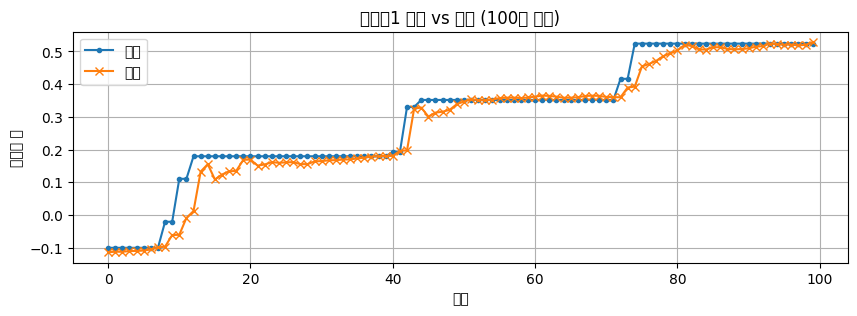

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


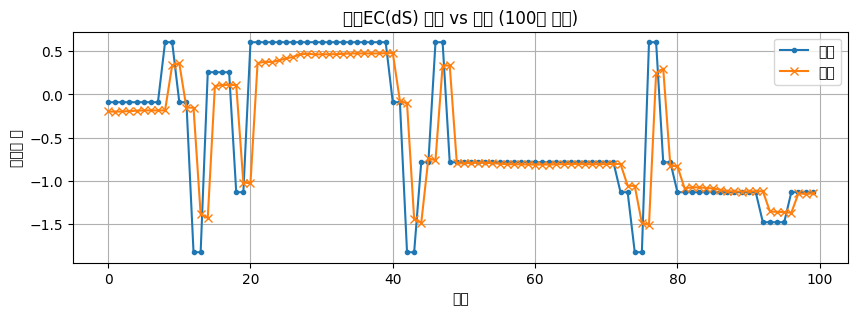

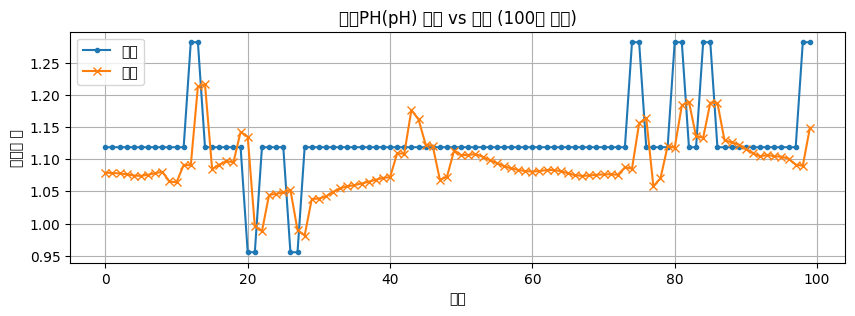

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


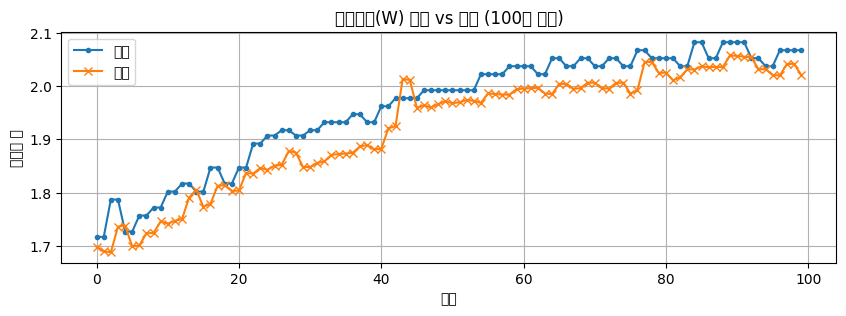

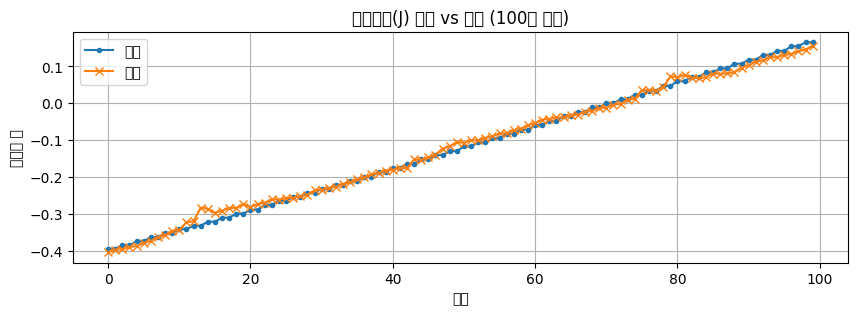

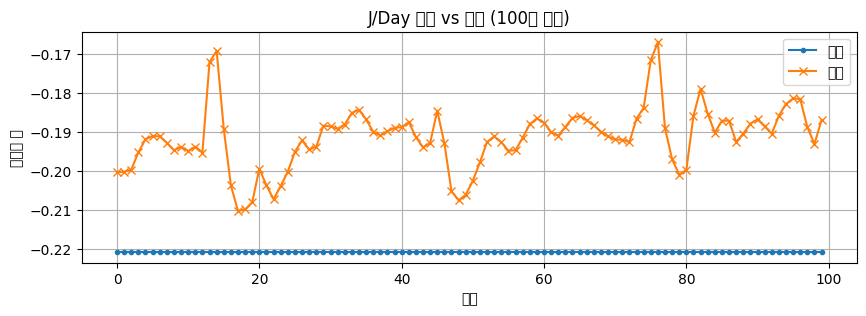

In [ ]:
import matplotlib.pyplot as plt

sensor_names = selected_cols  # ['누적량1', '현재EC(dS)', ...] 등

for i, sensor in enumerate(sensor_names):
    plt.figure(figsize=(10, 3))
    plt.plot(targets[:100, i], label='실제', marker='.')
    plt.plot(predictions[:100, i], label='예측', marker='x')
    plt.title(f"{sensor} 예측 vs 실제 (100개 샘플)")
    plt.xlabel("샘플")
    plt.ylabel("정규화 값")
    plt.legend()
    plt.grid(True)
    plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

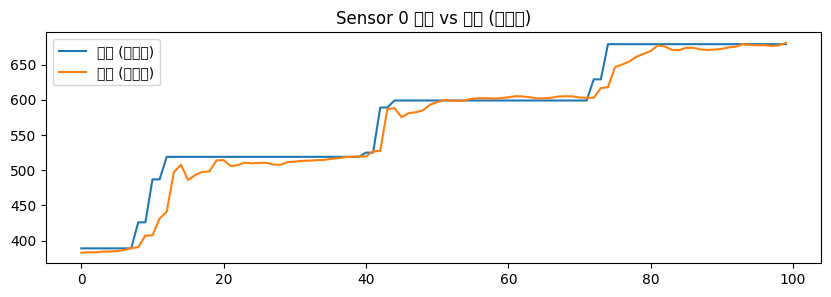

In [ ]:
# 예측값을 역정규화
pred_inv = scaler.inverse_transform(predictions)
true_inv = scaler.inverse_transform(targets)

# 예시 시각화
plt.figure(figsize=(10, 3))
plt.plot(true_inv[:100, 0], label='실제 (원단위)')
plt.plot(pred_inv[:100, 0], label='예측 (원단위)')
plt.title("Sensor 0 예측 vs 실제 (원단위)")
plt.legend()
plt.show()
